<a href="https://colab.research.google.com/github/teklewold24/my-colab-project/blob/main/Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms


In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [4]:
print("length of Train Dataset:", len(train_dataset))
print("length of Test Dataset:", len(test_dataset))

image, label = train_dataset[0]

print(image.shape)
print(label)

length of Train Dataset: 60000
length of Test Dataset: 10000
torch.Size([1, 28, 28])
5


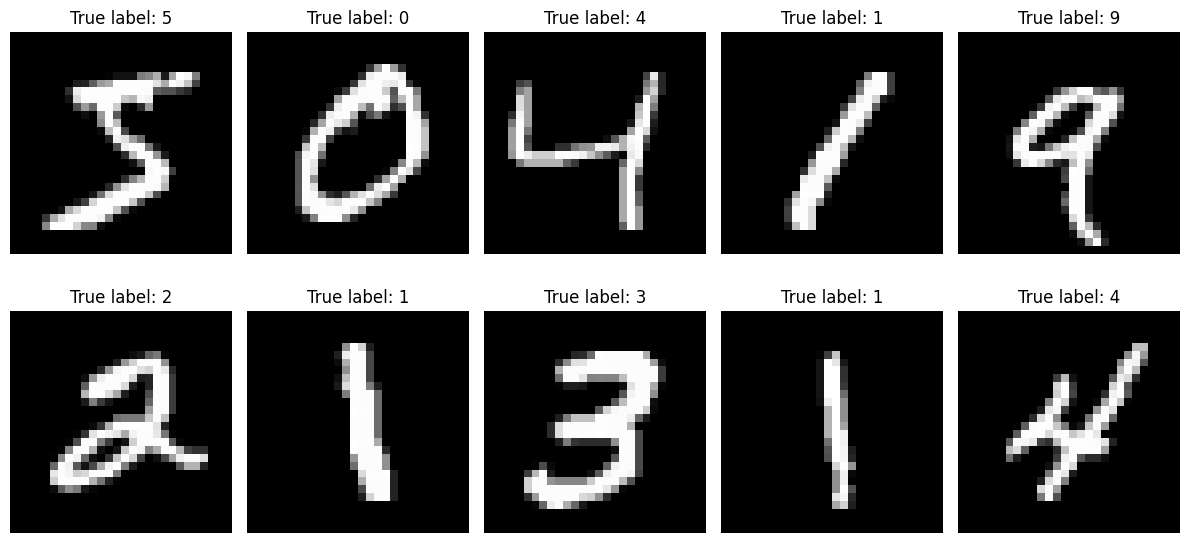

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

# Display 10 sample images
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"True label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Get one image and its label
image, label = train_dataset[0]

# Inspect the image
print("Image shape:", image.shape)
print("Image data type:", image.dtype)

# Inspect the label
print("Label:", label)
print("Label data type:", type(label))

# Inspect the pixel values
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Image shape: torch.Size([1, 28, 28])
Image data type: torch.float32
Label: 5
Label data type: <class 'int'>
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
from torch.utils.data import DataLoader

train_loader= DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader= DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Number of Train Batch:",len(train_loader))
print("Number of Test Batch:",len(test_loader))

Number of Train Batch: 938
Number of Test Batch: 157


In [8]:
for image,label in train_loader:
  print(image.shape)
  print(label.shape)

  break


torch.Size([64, 1, 28, 28])
torch.Size([64])


In [9]:
image , label = train_dataset[0]
print(image.shape)
print(label)
flatten_image = image.flatten()
print(flatten_image.shape)

torch.Size([1, 28, 28])
5
torch.Size([784])


In [10]:
images , labels = next(iter(train_loader))
print(images.shape)
print(labels)
flatten_image = images.flatten(start_dim=1)
print(flatten_image.shape)

torch.Size([64, 1, 28, 28])
tensor([6, 0, 5, 3, 5, 7, 3, 6, 8, 9, 3, 1, 6, 5, 9, 0, 7, 1, 1, 7, 7, 6, 8, 7,
        7, 3, 5, 2, 9, 0, 3, 0, 3, 6, 3, 0, 4, 9, 3, 6, 1, 7, 1, 7, 8, 4, 0, 7,
        3, 1, 3, 4, 2, 7, 4, 1, 1, 8, 0, 9, 3, 4, 6, 2])
torch.Size([64, 784])


In [11]:
class MNISTModel(nn.Module):
  def __init__(self):
      super().__init__()
      self.linear1=nn.Linear(in_features=784,out_features=128)
      self.linear2=nn.Linear(in_features=128,out_features=10)
      self.relu=nn.ReLU()

  def forward(self,x):
      x=self.linear1(x)
      x=self.relu(x)
      x=self.linear2(x)
      return x


model=MNISTModel()
print(model)

MNISTModel(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [12]:
images, labels = next(iter(train_loader))
images=images.flatten(start_dim=1)

model.eval()

with torch.no_grad():
    logits = model(images)
print(logits.shape)


torch.Size([64, 10])


In [13]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [16]:
model.eval()

with torch.no_grad():
    logits = model(images)
    loss = loss_fn(logits, labels)
print(logits.shape)
print(loss)

torch.Size([16, 10])
tensor(0.0014)


In [17]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc



In [22]:
epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    for images, labels in train_loader:
        images = images.flatten(start_dim=1)
        optimizer.zero_grad()
        logits = model(images)
        preds=logits.argmax(dim=1)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += accuracy_fn(labels, preds)

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.flatten(start_dim=1)
            logits = model(images)
            preds=logits.argmax(dim=1)
            loss = loss_fn(logits, labels)
            test_loss += loss.item()
            test_acc += accuracy_fn(labels, preds)


    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
    print(
        f"Epoch: {epoch + 1}, "
        f"Train Loss: {train_loss:.2f}, Train accuracy:{train_acc:2f}"
        f"Test Loss: {test_loss:.2f}, Test accuracy:{test_acc:2f}"
    )


Epoch: 1, Train Loss: 0.01, Train accuracy:99.868404Test Loss: 0.10, Test accuracy:97.760748
Epoch: 2, Train Loss: 0.00, Train accuracy:99.943364Test Loss: 0.09, Test accuracy:97.919984
Epoch: 3, Train Loss: 0.00, Train accuracy:99.998334Test Loss: 0.09, Test accuracy:98.059315
Epoch: 4, Train Loss: 0.00, Train accuracy:99.996668Test Loss: 0.10, Test accuracy:97.919984
Epoch: 5, Train Loss: 0.01, Train accuracy:99.683502Test Loss: 0.10, Test accuracy:97.890127


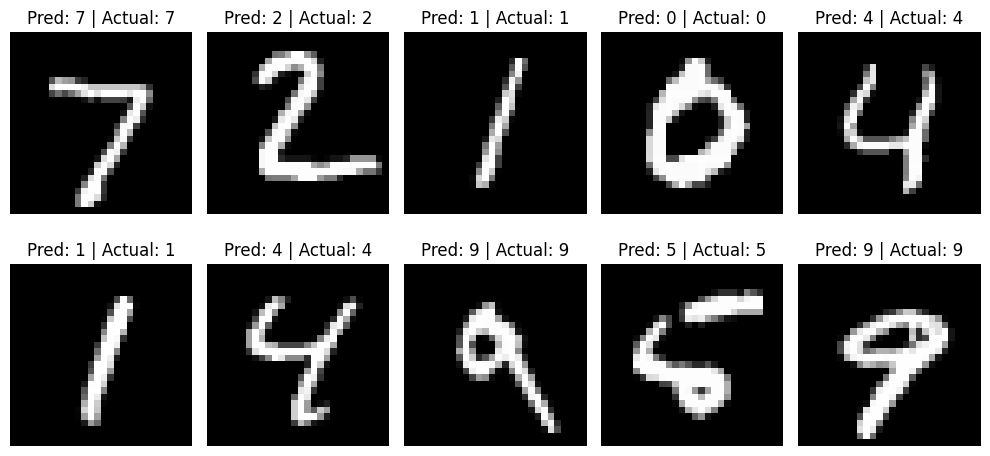

In [26]:
model.eval()

with torch.no_grad():

    # 1. Get one batch from the test loader
    images, labels = next(iter(test_loader))

    # Keep the original images for displaying
    original_images = images

    # 2. Flatten images for the model
    images = images.flatten(start_dim=1)

    # 3. Generate logits
    logits = model(images)

    # 4. Convert logits to predicted digits
    preds = logits.argmax(dim=1)

# 5. Create a 2 × 5 grid
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# 6. Display the first 10 images
for i in range(10):
    axes[i // 5, i % 5].imshow(
        original_images[i].squeeze(),
        cmap="gray"
    )

    axes[i // 5, i % 5].set_title(
        f"Pred: {preds[i].item()} | Actual: {labels[i].item()}"
    )

    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()



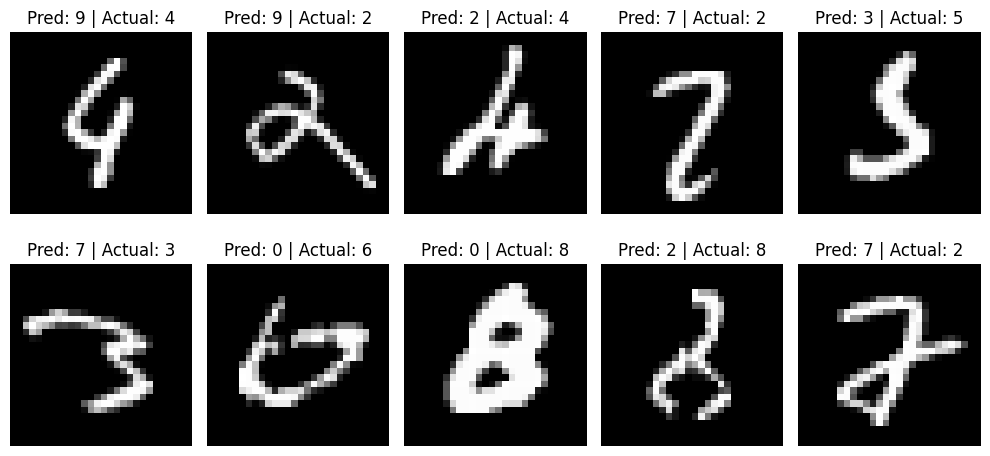

In [28]:

model.eval()

# Lists to store incorrect predictions
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():

    # Go through the test batches
    for images, labels in test_loader:

        # Keep original images for displaying
        original_images = images

        # Flatten images for the model
        images = images.flatten(start_dim=1)

        # Generate logits
        logits = model(images)

        # Convert logits to predicted digits
        preds = logits.argmax(dim=1)

        # Find which predictions are incorrect
        incorrect = preds != labels

        # Collect the incorrect predictions
        for i in range(len(images)):

            if incorrect[i]:
                wrong_images.append(original_images[i])
                wrong_preds.append(preds[i])
                wrong_labels.append(labels[i])

            # Stop when we have 10 wrong predictions
            if len(wrong_images) == 10:
                break

        # Stop checking more batches once we have 10
        if len(wrong_images) == 10:
            break


# Create a 2 × 5 grid
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Display the 10 incorrect predictions
for i in range(10):

    axes[i // 5, i % 5].imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    axes[i // 5, i % 5].set_title(
        f"Pred: {wrong_preds[i].item()} | Actual: {wrong_labels[i].item()}"
    )

    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()



Labels shape: torch.Size([10000])
Predictions shape: torch.Size([10000])


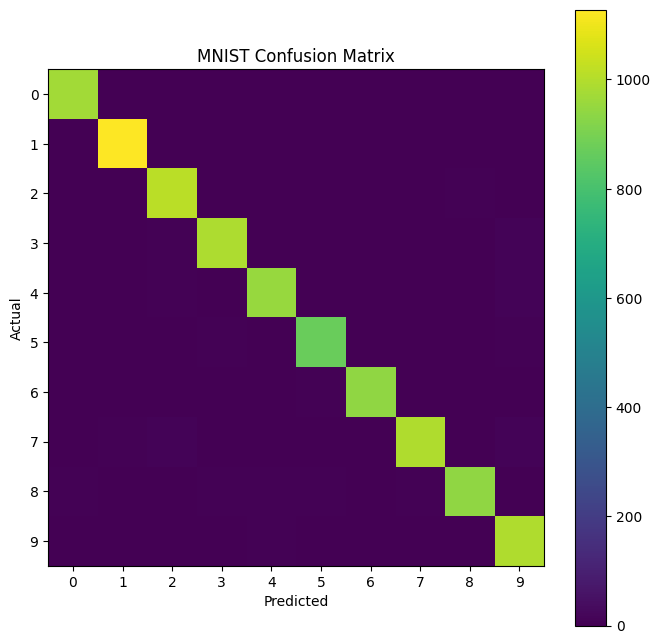

In [29]:
model.eval()

# Store all actual labels and predictions
all_labels = []
all_preds = []

with torch.no_grad():

    # Go through every batch in the test set
    for images, labels in test_loader:

        # Flatten images
        images = images.flatten(start_dim=1)

        # Get model predictions
        logits = model(images)
        preds = logits.argmax(dim=1)

        # Store labels and predictions
        all_labels.append(labels)
        all_preds.append(preds)


# Combine all batches into one tensor
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

print("Labels shape:", all_labels.shape)
print("Predictions shape:", all_preds.shape)


# Create a 10 × 10 confusion matrix
confusion_matrix = torch.zeros(10, 10, dtype=torch.int64)

for actual, predicted in zip(all_labels, all_preds):
    confusion_matrix[actual, predicted] += 1


# Convert to NumPy for matplotlib
confusion_matrix = confusion_matrix.numpy()


# Display the confusion matrix
plt.figure(figsize=(8, 8))

plt.imshow(confusion_matrix)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.title("MNIST Confusion Matrix")

plt.show()

